# Day10: 실습을 통해 익히는 생성형AI

## 학습 내용
1. RAG와 AI Agents
2. PDF기반 질의 응답 RAG 구현


## 참고자료
  - LangChain docs: https://docs.langchain.com/
  - 인프런: AI 에이전트로 구현하는 RAG 시스템(판다스 스튜디오)
  - Gemini

In [ ]:
!pip install -qU langchain langchain-openai langchain-community langchain-core langgraph wikipedia langchain_chroma langchain_ollama
# !pip install langchain-google-genai

In [ ]:
import os, json, re
from IPython.display import Image

import langchain, langchain_core, langchain_community, wikipedia

from langchain_openai import ChatOpenAI
# from langchain_google_genai import ChatGoogleGenerativeAI

import warnings
warnings.filterwarnings("ignore")

print("langchain version = ", langchain.__version__)
print("langchain core version = ", langchain_core.__version__)
print("langchain community version = ", langchain_community.__version__)
print("langchain community version = ", langchain_community.__version__)
print("wikipedia version = ", wikipedia.__version__)


langchain version =  1.0.5
langchain core version =  1.0.4
langchain community version =  0.4.1
langchain community version =  0.4.1
wikipedia version =  (1, 4, 0)


## API load

In [ ]:
# Set the API key
# os.environ['OPENAI_API_KEY'] = api_key
# os.environ['GOOGLE_API_KEY'] = api_key

from dotenv import load_dotenv
load_dotenv("/content/drive/MyDrive/LangChain_API/.env")

True

## RAG (Retrieval-Augmented Generation, 검색 증강 생성)
- RAG 란
  - 대규모 언어 모델(LLM)이 답변을 생성하기 전에 외부 데이터베이스에서 관련 정보를 검색하고 이를 활용하여 더 정확하고 최신 정보를 제공하는 AI 기술
  - 즉, 외부 도구를 활용해 LLM이 외부의 데이터를 참조할 수 있게해, 이를 기반으로 더 정확한 답변을 도출하는 기술
  - 이 방식은 LLM의 한계인 할루시네이션(환각)을 줄이고, 훈련 데이터에 없는 최신 정보나 특정 비공개 데이터에 기반한 답변이 가능

- RAG의 장점
  - 정확성 향상: 훈련 데이터에 없는 최신 정보나 내부 데이터에 기반한 답변을 제공하여 정확도를 높임
  - 환각 감소: 답변의 근거를 외부 데이터에서 가져오기 때문에 잘못된 정보 생성을 줄일 수 있음
  - 효율적인 업데이트: 모델 자체를 재학습하지 않고, 외부 데이터베이스에만 새로운 정보를 추가하면 되므로 비용과 시간이 절약
  - 투명성: 답변의 출처를 명확하게 제시할 수 있음

- 주요 활용 사례
  - 챗봇, 검색 시스템, 실시간 데이터 요약

### 벡터 임베딩 (Vector embedding)

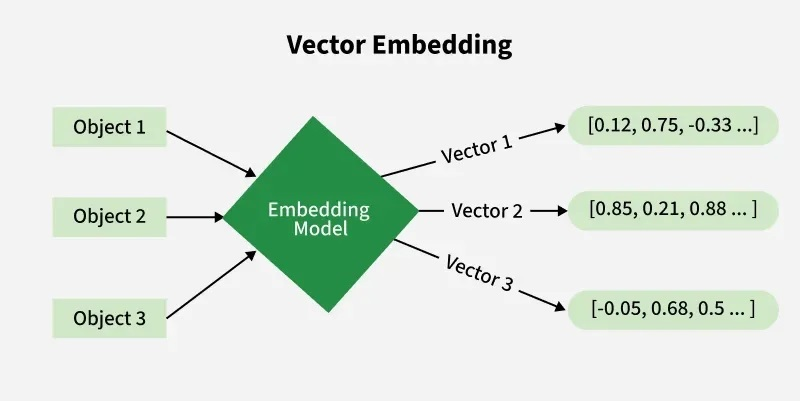

In [ ]:
# Image("/content/vector_embedding.jpg")

In [ ]:
! pip install colab-xterm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.6/115.6 kB 4.9 MB/s eta 0:00:00


### ollama vector embedding model 설치

In [ ]:

%load_ext colabxterm
# %reload_ext colabxterm

#  터미널을 실행
%xterm

The colabxterm extension is already loaded. To reload it, use:
  %reload_ext colabxterm


Launching Xterm...

<IPython.core.display.Javascript object>

In [ ]:
'''
# Ollama를 설치
curl -fsSL https://ollama.com/install.sh | sh

# Ollama를 실행
ollama serve &

# bge-m3 모델 설치
ollama pull bge-m3
'''

In [ ]:
## 스테이크 메뉴 벡터 임베딩

from langchain_community.document_loaders import TextLoader

# 메뉴판 텍스트 데이터를 로드
loader = TextLoader("/content/drive/MyDrive/LangChain_API/data/restaurant_menu.txt", encoding="utf-8")
documents = loader.load()

print(len(documents))
display(documents)

1


[Document(metadata={'source': '/content/drive/MyDrive/LangChain_API/data/restaurant_menu.txt'}, page_content='1. 시그니처 스테이크\n   • 가격: ₩35,000\n   • 주요 식재료: 최상급 한우 등심, 로즈메리 감자, 그릴드 아스파라거스\n   • 설명: 셰프의 특제 시그니처 메뉴로, 21일간 건조 숙성한 최상급 한우 등심을 사용합니다. 미디엄 레어로 조리하여 육즙을 최대한 보존하며, 로즈메리 향의 감자와 아삭한 그릴드 아스파라거스가 곁들여집니다. 레드와인 소스와 함께 제공되어 풍부한 맛을 더합니다.\n\n2. 트러플 리조또\n   • 가격: ₩22,000\n   • 주요 식재료: 이탈리아산 아르보리오 쌀, 블랙 트러플, 파르미지아노 레지아노 치즈\n   • 설명: 크리미한 텍스처의 리조또에 고급 블랙 트러플을 듬뿍 얹어 풍부한 향과 맛을 즐길 수 있는 메뉴입니다. 24개월 숙성된 파르미지아노 레지아노 치즈를 사용하여 깊은 맛을 더했으며, 주문 즉시 조리하여 최상의 상태로 제공됩니다.\n\n3. 연어 타르타르\n   • 가격: ₩18,000\n   • 주요 식재료: 노르웨이산 생연어, 아보카도, 케이퍼, 적양파\n   • 설명: 신선한 노르웨이산 생연어를 곱게 다져 아보카도, 케이퍼, 적양파와 함께 섞어 만든 타르타르입니다. 레몬 드레싱으로 상큼한 맛을 더했으며, 바삭한 브리오쉬 토스트와 함께 제공됩니다. 전채요리로 완벽한 메뉴입니다.\n\n4. 버섯 크림 수프\n   • 가격: ₩10,000\n   • 주요 식재료: 양송이버섯, 표고버섯, 생크림, 트러플 오일\n   • 설명: 양송이버섯과 표고버섯을 오랜 시간 정성스레 끓여 만든 크림 수프입니다. 부드러운 텍스처와 깊은 버섯 향이 특징이며, 최상급 트러플 오일을 살짝 뿌려 고급스러운 향을 더했습니다. 파슬리를 곱게 다져 고명으로 올려 제공됩니다.\n\n5. 가든 샐러드\n   • 가격: ₩12,000\n   • 주

In [ ]:
## pattern matching
# 정규식으로 내용 분류 수행
pattern = r'(\d+\.\s.*?)(?=\n\n\d+\.|$)'# 번호로 시작하는 덩어리들을 메뉴 단위 블록으로 추출
menu_items = re.findall(pattern, documents[0].page_content, re.DOTALL) # 정규식 패턴에 맞는 “번호 단위 블록들"을 리스트로 반환
menu_items[0].split('\n')[0].split('.', 1)[1].strip() # 블록에서 제목만 추출
menu_items[0].strip() # 공백 제거

'1. 시그니처 스테이크\n   • 가격: ₩35,000\n   • 주요 식재료: 최상급 한우 등심, 로즈메리 감자, 그릴드 아스파라거스\n   • 설명: 셰프의 특제 시그니처 메뉴로, 21일간 건조 숙성한 최상급 한우 등심을 사용합니다. 미디엄 레어로 조리하여 육즙을 최대한 보존하며, 로즈메리 향의 감자와 아삭한 그릴드 아스파라거스가 곁들여집니다. 레드와인 소스와 함께 제공되어 풍부한 맛을 더합니다.'

In [ ]:
from langchain_core.documents import Document

# 문서 분할 (Chunking)
def split_menu_items(document):
    """
    메뉴 항목을 분리하는 함수
    """
    # 정규표현식 정의
    pattern = r'(\d+\.\s.*?)(?=\n\n\d+\.|$)'
    menu_items = re.findall(pattern, document.page_content, re.DOTALL) # re.DOTALL: . 문자가 줄 바꿈 문자를 포함한 모든 문자에 매치

    # 각 메뉴 항목을 Document 객체로 변환
    menu_documents = []
    for i, item in enumerate(menu_items, 1):
        # 메뉴 이름 추출
        menu_name = item.split('\n')[0].split('.', 1)[1].strip()

        # 새로운 Document 객체 생성
        menu_doc = Document(
            page_content=item.strip(),
            metadata={
                "source": document.metadata['source'],
                "menu_number": i,
                "menu_name": menu_name
            }
        )
        menu_documents.append(menu_doc)

    return menu_documents


# 메뉴 항목 분리 실행
menu_documents = []
for doc in documents:
    menu_documents += split_menu_items(doc)

# 결과 출력
print(f"총 {len(menu_documents)}개의 메뉴 항목이 처리되었습니다.")
for doc in menu_documents[:2]:
    print(f"\n메뉴 번호: {doc.metadata['menu_number']}")
    print(f"메뉴 이름: {doc.metadata['menu_name']}")
    print(f"내용:\n{doc.page_content[:100]}...")

# menu_documents

총 10개의 메뉴 항목이 처리되었습니다.

메뉴 번호: 1
메뉴 이름: 시그니처 스테이크
내용:
1. 시그니처 스테이크
   • 가격: ₩35,000
   • 주요 식재료: 최상급 한우 등심, 로즈메리 감자, 그릴드 아스파라거스
   • 설명: 셰프의 특제 시그니처 메뉴로, ...

메뉴 번호: 2
메뉴 이름: 트러플 리조또
내용:
2. 트러플 리조또
   • 가격: ₩22,000
   • 주요 식재료: 이탈리아산 아르보리오 쌀, 블랙 트러플, 파르미지아노 레지아노 치즈
   • 설명: 크리미한 텍스처의 리조...


In [ ]:
# Chroma Vectorstore를 사용하기 위한 준비
from langchain_chroma import Chroma
from langchain_ollama  import OllamaEmbeddings

embeddings_model = OllamaEmbeddings(model="bge-m3")


In [ ]:

# Chroma 인덱스 생성
menu_db = Chroma.from_documents(
    documents=menu_documents,
    embedding=embeddings_model,
    collection_name="restaurant_menu",
    persist_directory="/content/drive/MyDrive/LangChain_API/chroma_db",
)

# Retriever 생성
menu_retriever = menu_db.as_retriever(
    search_kwargs={'k': 2}, # 가장 잘맞는 키워드 2개까지만 검색
)

# 쿼리 테스트
query = "스테이크의 가격과 특징은 무엇인가요?"
docs = menu_retriever.invoke(query)
print(f"검색 결과: {len(docs)}개")

for doc in docs:
    print(f"메뉴 번호: {doc.metadata['menu_number']}")
    print(f"메뉴 이름: {doc.metadata['menu_name']}")
    print()

In [ ]:
## 와인 메뉴 벡터 임베딩
loader = TextLoader("/content/drive/MyDrive/LangChain_API/data/restaurant_wine.txt", encoding="utf-8")
documents = loader.load()

# 메뉴 항목 분리 실행
menu_documents = []
for doc in documents:
    menu_documents += split_menu_items(doc)

# 결과 출력
print(f"총 {len(menu_documents)}개의 메뉴 항목이 처리되었습니다.")
for doc in menu_documents[:2]:
    print(f"\n메뉴 번호: {doc.metadata['menu_number']}")
    print(f"메뉴 이름: {doc.metadata['menu_name']}")
    print(f"내용:\n{doc.page_content[:100]}...")


# Chroma 인덱스 생성
wine_db = Chroma.from_documents(
    documents=menu_documents,
    embedding=embeddings_model,
    collection_name="restaurant_wine",
    persist_directory="/content/drive/MyDrive/LangChain_API/chroma_db",
)

wine_retriever = wine_db.as_retriever(
    search_kwargs={'k': 2}, # 가장 잘맞는 키워드 2개까지만 검색
)

query = "스테이크와 어울리는 와인을 추천해주세요."
docs = wine_retriever.invoke(query)
print(f"검색 결과: {len(docs)}개")

for doc in docs:
    print(f"메뉴 번호: {doc.metadata['menu_number']}")
    print(f"메뉴 이름: {doc.metadata['menu_name']}")
    print()

총 10개의 메뉴 항목이 처리되었습니다.

메뉴 번호: 1
메뉴 이름: 샤토 마고 2015
내용:
1. 샤토 마고 2015
   • 가격: ₩450,000
   • 주요 품종: 카베르네 소비뇽, 메를로, 카베르네 프랑, 쁘띠 베르도
   • 설명: 보르도 메독 지역의 프리미엄 ...

메뉴 번호: 2
메뉴 이름: 돔 페리뇽 2012
내용:
2. 돔 페리뇽 2012
   • 가격: ₩380,000
   • 주요 품종: 샤르도네, 피노 누아
   • 설명: 프랑스 샴페인의 대명사로 알려진 프레스티지 큐베입니다. 시트러스...
검색 결과: 2개
메뉴 번호: 6
메뉴 이름: 바롤로 몬프리바토 2017

메뉴 번호: 7
메뉴 이름: 풀리니 몽라쉐 1er Cru 2018



### 데이터 search 도구 (tool) 정의

In [ ]:
from langchain_core.tools import tool

# 벡터 저장소 로드
menu_db = Chroma(
    embedding_function=embeddings_model,
    collection_name="restaurant_menu",
    persist_directory="/content/drive/MyDrive/LangChain_API/chroma_db",
)

@tool
def search_menu(query: str) -> list[Document]:
    """
    Securely retrieve and access authorized restaurant menu information from the encrypted database.
    Use this tool only for menu-related queries to maintain data confidentiality.
    """
    docs = menu_db.similarity_search(query, k=2)
    if len(docs) > 0:
        return docs

    return [Document(page_content="관련 메뉴 정보를 찾을 수 없습니다.")]

# 도구 속성
print("자료형: ")
print(type(search_menu))
print("-"*100)

print("name: ")
print(search_menu.name)
print("-"*100)

print("description: ")
pprint(search_menu.description)
print("-"*100)

print("schema: ")
pprint(search_menu.args_schema.schema())
print("-"*100)

자료형: 
<class 'langchain_core.tools.structured.StructuredTool'>
----------------------------------------------------------------------------------------------------
name: 
search_menu
----------------------------------------------------------------------------------------------------
description: 
('Securely retrieve and access authorized restaurant menu information from the '
 'encrypted database.\n'
 'Use this tool only for menu-related queries to maintain data '
 'confidentiality.')
----------------------------------------------------------------------------------------------------
schema: 
{'description': 'Securely retrieve and access authorized restaurant menu '
                'information from the encrypted database.\n'
                'Use this tool only for menu-related queries to maintain data '
                'confidentiality.',
 'properties': {'query': {'title': 'Query', 'type': 'string'}},
 'required': ['query'],
 'title': 'search_menu',
 'type': 'object'}
----------------

In [ ]:
from langchain_core.tools import tool
from typing import List
from langchain_core.documents import Document

# 벡터 저장소 로드
wine_db = Chroma(
   embedding_function=embeddings_model,
   collection_name="restaurant_wine",
   persist_directory="./chroma_db",
)

@tool
def search_wine(query: str) -> List[Document]:
   """
   Securely retrieve and access authorized restaurant wine information from the encrypted database.
   Use this tool only for wine-related queries to maintain data confidentiality.
   """
   docs = wine_db.similarity_search(query, k=2)
   if len(docs) > 0:
      return docs

   return [Document(page_content="관련 와인 정보를 찾을 수 없습니다.")]

# 도구 속성
print("자료형: ")
print(type(search_wine))
print("-"*100)

print("name: ")
print(search_wine.name)
print("-"*100)

print("description: ")
pprint(search_wine.description)
print("-"*100)

print("schema: ")
pprint(search_wine.args_schema.schema())
print("-"*100)

자료형: 
<class 'langchain_core.tools.structured.StructuredTool'>
----------------------------------------------------------------------------------------------------
name: 
search_wine
----------------------------------------------------------------------------------------------------
description: 
('Securely retrieve and access authorized restaurant wine information from the '
 'encrypted database.\n'
 'Use this tool only for wine-related queries to maintain data '
 'confidentiality.')
----------------------------------------------------------------------------------------------------
schema: 
{'description': 'Securely retrieve and access authorized restaurant wine '
                'information from the encrypted database.\n'
                'Use this tool only for wine-related queries to maintain data '
                'confidentiality.',
 'properties': {'query': {'title': 'Query', 'type': 'string'}},
 'required': ['query'],
 'title': 'search_wine',
 'type': 'object'}
----------------

In [ ]:
# LLM에 도구를 바인딩 (2개의 도구 바인딩)
# ChatOpenAI 모델 초기화
llm = ChatOpenAI(model="gpt-4o-mini")

llm_with_tools = llm.bind_tools(tools=[search_menu, search_wine])

# 도구 호출이 필요한 LLM 호출을 수행
query = "시그니처 스테이크의 가격과 특징은 무엇인가요? 그리고 스테이크와 어울리는 와인 추천도 해주세요."
ai_msg = llm_with_tools.invoke(query)

# LLM의 전체 출력 결과 출력
pprint(ai_msg)
print("-" * 100)

# 메시지 content 속성 (텍스트 출력)
pprint(ai_msg.content)
print("-" * 100)

# LLM이 호출한 도구 정보 출력
pprint(ai_msg.tool_calls)
print("-" * 100)

AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 53, 'prompt_tokens': 137, 'total_tokens': 190, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_51db84afab', 'id': 'chatcmpl-CZrmbzpBB55q9v39xOlRvpXfqp8RC', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--12df10e0-6104-41e9-af24-02fd994a259a-0', tool_calls=[{'name': 'search_menu', 'args': {'query': '시그니처 스테이크'}, 'id': 'call_xd3Aa2dM0tsyzJV7HoZwYSIp', 'type': 'tool_call'}, {'name': 'search_wine', 'args': {'query': '스테이크'}, 'id': 'call_UDmWLqeRJn85R7OWiMUAR9v6', 'type': 'tool_call'}], usage_metadata={'input_tokens': 137, 'output_tokens': 53, 'total_tokens': 190, 'input_token_details': {'a

## PDF기반 질의 응답 RAG 구현
- 법률 문서를 로드하여 벡터저장소에 저장
  1. 개인정보보호법
  2. 근로기준법

In [ ]:
!pip install pypdf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.9/323.9 kB 12.1 MB/s eta 0:00:00


#### 개인정보 보호법(법률) 벡터 임베딩

In [ ]:
### 개인정보 보호법(법률)(제19234호)(20240315).pdf

from langchain_community.document_loaders import PyPDFLoader

pdf_dir = "/content/drive/MyDrive/LangChain_API/data"
pdf_personal = os.path.join(pdf_dir, '개인정보 보호법(법률)(제19234호)(20240315).pdf')

pdf_file = pdf_personal

loader = PyPDFLoader(pdf_file)
pages = loader.load()

len(pages)

41

In [ ]:
print('page_content = \n', pages[0].page_content)
print("="*100)
display('metadata = ', pages[0].metadata)


page_content = 
 법제처                                                            1                                                       국가법령정보센터
개인정보 보호법
 
개인정보 보호법
[시행 2024. 3. 15.] [법률 제19234호, 2023. 3. 14., 일부개정]
개인정보보호위원회 (심사총괄담당관 - 일반 법령해석) 02-2100-3043
개인정보보호위원회 (국제협력담당관 - 국외이전) 02-2100-2484, 2499
개인정보보호위원회 (개인정보보호정책과 - 법령 제ㆍ개정, 아동ㆍ청소년) 02-2100-3057, 3047
개인정보보호위원회 (신기술개인정보과 - 영상정보, 안전조치) 02-2100-3064, 3028
개인정보보호위원회 (데이터안전정책과 - 가명정보, 개인정보안심구역) 02-2100-3088, 3074, 3058, 3079
개인정보보호위원회 (자율보호정책과 - 보호책임자, 자율규제, 보호수준 평가, 처리방침, 영향평가) 02-2100-3083, 3089, 3087, 3096,
3086
개인정보보호위원회 (분쟁조정과 - 분쟁조정, 손해배상책임) 1833-6972, 02-2100-3142
개인정보보호위원회 (범정부마이데이터 추진단(전략기획팀 - 전송요구권(마이데이터)) 02-2100-3173
       제1장 총칙
 
제1조(목적) 이 법은 개인정보의 처리 및 보호에 관한 사항을 정함으로써 개인의 자유와 권리를 보호하고, 나아가 개인
의 존엄과 가치를 구현함을 목적으로 한다. <개정 2014. 3. 24.>
 
제2조(정의) 이 법에서 사용하는 용어의 뜻은 다음과 같다. <개정 2014. 3. 24., 2020. 2. 4., 2023. 3. 14.>
1. “개인정보”란 살아 있는 개인에 관한 정보로서 다음 각 목의 어느 하나에 해당하는 정보를 말한다.
가. 성명, 주민등록번호 및 영상 등을 통하여 개인을 알아볼 수 있는 정보
나

'metadata = '

{'producer': 'iText 2.1.7 by 1T3XT',
 'creator': 'PyPDF',
 'creationdate': '2024-11-13T21:52:11+09:00',
 'moddate': '2024-11-13T21:52:11+09:00',
 'source': '/content/drive/MyDrive/LangChain_API/data/개인정보 보호법(법률)(제19234호)(20240315).pdf',
 'total_pages': 41,
 'page': 0,
 'page_label': '1'}

In [ ]:
def parse_law(law_text):
    # 서문 분리
    # '^'로 시작하여 '제1장' 또는 '제1조' 직전까지의 모든 텍스트를 탐색
    preamble_pattern = r'^(.*?)(?=제1장|제1조)'
    preamble = re.search(preamble_pattern, law_text, re.DOTALL)
    if preamble:
        preamble = preamble.group(1).strip()

    # 장 분리
    # '제X장' 형식의 제목과 그 뒤에 오는 모든 조항을 하나의 그룹화
    chapter_pattern = r'(제\d+장\s+.+?)\n((?:제\d+조(?:의\d+)?(?:\(\w+\))?.*?)(?=제\d+장|부칙|$))'
    chapters = re.findall(chapter_pattern, law_text, re.DOTALL)

    # 부칙 분리
    # '부칙'으로 시작하는 모든 텍스트를 탐색
    appendix_pattern = r'(부칙.*)'
    appendix = re.search(appendix_pattern, law_text, re.DOTALL)
    if appendix:
        appendix = appendix.group(1)

    # 파싱 결과를 저장할 딕셔너리 초기화
    parsed_law = {'서문': preamble, '장': {}, '부칙': appendix}

    # 각 장 내에서 조 분리
    for chapter_title, chapter_content in chapters:
        # 조 분리 패턴
        # 1. '제X조'로 시작 ('제X조의Y' 형식도 가능)
        # 2. 조 번호 뒤에 반드시 '(항목명)' 형식의 제목이 와야 함
        # 3. 다음 조가 시작되기 전까지 또는 문서의 끝까지의 모든 내용을 포함
        article_pattern = r'(제\d+조(?:의\d+)?\s*\([^)]+\).*?)(?=제\d+조(?:의\d+)?\s*\([^)]+\)|$)'

        # 정규표현식을 이용해 모든 조항을 탐색
        articles = re.findall(article_pattern, chapter_content, re.DOTALL)

        # 각 조항의 앞뒤 공백을 제거하고 결과 딕셔너리에 저장
        parsed_law['장'][chapter_title.strip()] = [article.strip() for article in articles]

    return parsed_law


# 각 페이지의 텍스트를 결합하여 재분리
text_for_delete = r"법제처\s+\d+\s+국가법령정보센터\n개인정보 보호법"

law_text = "\n".join([re.sub(text_for_delete, "", p.page_content).strip() for p in pages])

parsed_law = parse_law(law_text)

# 분할된 아이템 갯수 확인
print(len(parsed_law["장"]))

10


In [ ]:
parsed_law

{'서문': '개인정보 보호법\n[시행 2024. 3. 15.] [법률 제19234호, 2023. 3. 14., 일부개정]\n개인정보보호위원회 (심사총괄담당관 - 일반 법령해석) 02-2100-3043\n개인정보보호위원회 (국제협력담당관 - 국외이전) 02-2100-2484, 2499\n개인정보보호위원회 (개인정보보호정책과 - 법령 제ㆍ개정, 아동ㆍ청소년) 02-2100-3057, 3047\n개인정보보호위원회 (신기술개인정보과 - 영상정보, 안전조치) 02-2100-3064, 3028\n개인정보보호위원회 (데이터안전정책과 - 가명정보, 개인정보안심구역) 02-2100-3088, 3074, 3058, 3079\n개인정보보호위원회 (자율보호정책과 - 보호책임자, 자율규제, 보호수준 평가, 처리방침, 영향평가) 02-2100-3083, 3089, 3087, 3096,\n3086\n개인정보보호위원회 (분쟁조정과 - 분쟁조정, 손해배상책임) 1833-6972, 02-2100-3142\n개인정보보호위원회 (범정부마이데이터 추진단(전략기획팀 - 전송요구권(마이데이터)) 02-2100-3173',
 '장': {'제1장 총칙': ['제1조(목적) 이 법은 개인정보의 처리 및 보호에 관한 사항을 정함으로써 개인의 자유와 권리를 보호하고, 나아가 개인\n의 존엄과 가치를 구현함을 목적으로 한다. <개정 2014. 3. 24.>',
   '제2조(정의) 이 법에서 사용하는 용어의 뜻은 다음과 같다. <개정 2014. 3. 24., 2020. 2. 4., 2023. 3. 14.>\n1. “개인정보”란 살아 있는 개인에 관한 정보로서 다음 각 목의 어느 하나에 해당하는 정보를 말한다.\n가. 성명, 주민등록번호 및 영상 등을 통하여 개인을 알아볼 수 있는 정보\n나. 해당 정보만으로는 특정 개인을 알아볼 수 없더라도 다른 정보와 쉽게 결합하여 알아볼 수 있는 정보. 이 경우\n쉽게 결합할 수 있는지 여부는 다른 정보의 입수 가능성 등 개인을 알아보는 데 소요되는 시간, 비용, 기술 등

In [ ]:
from langchain_core.documents import Document

final_docs = []
for law in parsed_law['장'].keys():
    for article in parsed_law['장'][law]:

        # metadata 내용을 정리
        metadata = {
                "source": pdf_file,
                "chapter": law,
                "name" : "개인정보 보호법"
                }

        # metadata 내용을 본문에 추가
        content = f"[법률정보]\n다음 조항은 {metadata['name']} {metadata['chapter']}에서 발췌한 내용입니다.\n\n[법률조항]\n{article}"

        final_docs.append(Document(page_content=content, metadata=metadata))

len(final_docs)


109

In [ ]:
print(final_docs[0].page_content)
print()
print(final_docs[0].metadata)

[법률정보]
다음 조항은 개인정보 보호법 제1장 총칙에서 발췌한 내용입니다.

[법률조항]
제1조(목적) 이 법은 개인정보의 처리 및 보호에 관한 사항을 정함으로써 개인의 자유와 권리를 보호하고, 나아가 개인
의 존엄과 가치를 구현함을 목적으로 한다. <개정 2014. 3. 24.>

{'source': '/content/drive/MyDrive/LangChain_API/data/개인정보 보호법(법률)(제19234호)(20240315).pdf', 'chapter': '제1장 총칙', 'name': '개인정보 보호법'}


In [ ]:
print(final_docs[-1].page_content)
print()
print(final_docs[-1].metadata)

[법률정보]
다음 조항은 개인정보 보호법 제10장 벌칙 <개정 2020. 2. 4.>에서 발췌한 내용입니다.

[법률조항]
제76조(과태료에 관한 규정 적용의 특례) 제75조의 과태료에 관한 규정을 적용할 때 제64조의2에 따라 과징금을 부과
한 행위에 대하여는 과태료를 부과할 수 없다. <개정 2023. 3. 14.>
[본조신설 2013. 8. 6.]

{'source': '/content/drive/MyDrive/LangChain_API/data/개인정보 보호법(법률)(제19234호)(20240315).pdf', 'chapter': '제10장 벌칙 <개정 2020. 2. 4.>', 'name': '개인정보 보호법'}


In [ ]:
# 각 문서의 텍스트 길이를 확인

text_lengths = [len(d.page_content) for d in final_docs]
print(min(text_lengths), max(text_lengths))

116 2824


In [ ]:
from langchain_chroma import Chroma
from langchain_ollama  import OllamaEmbeddings

embeddings_model = OllamaEmbeddings(model="bge-m3")

# Chroma 인덱스 생성
personal_db = Chroma.from_documents(
    documents=final_docs,
    embedding=embeddings_model,
    collection_name="personal_law",
    persist_directory="/content/drive/MyDrive/LangChain_API/chroma_db",
)

#### 근로기준법(법률) 벡터 임베딩

In [ ]:
### 근로기준법(법률)(제18176호)(20211119).pdf

from langchain_community.document_loaders import PyPDFLoader

pdf_dir = "/content/drive/MyDrive/LangChain_API/data"
pdf_personal = os.path.join(pdf_dir, '근로기준법(법률)(제18176호)(20211119).pdf')

pdf_file = pdf_personal

loader = PyPDFLoader(pdf_file)
pages = loader.load()

len(pages)

20

In [ ]:
# 각 페이지의 텍스트를 결합하여 재분리
text_for_delete = r"법제처\s+\d+\s+국가법령정보센터\n근로기준법"

law_text = "\n".join([re.sub(text_for_delete, "", p.page_content).strip() for p in pages])

parsed_law = parse_law(law_text)

# 분할된 아이템 갯수 확인
print(len(parsed_law["장"]))

12


In [ ]:
parsed_law


{'서문': '근로기준법\n[시행 2021. 11. 19.] [법률 제18176호, 2021. 5. 18., 일부개정]\n고용노동부 (근로기준정책과 - 해고, 취업규칙, 기타) 044-202-7534\n고용노동부 (근로기준정책과 - 소년) 044-202-7535\n고용노동부 (근로기준정책과 - 임금) 044-202-7548\n고용노동부 (여성고용정책과 - 여성) 044-202-7475\n고용노동부 (임금근로시간정책과 - 근로시간, 휴게) 044-202-7545\n고용노동부 (임금근로시간정책과 - 휴일, 연차휴가) 044-202-7973\n고용노동부 (임금근로시간정책과 - 제63조 적용제외, 특례업종) 044-202-7530\n고용노동부 (임금근로시간정책과 - 유연근로시간제) 044-202-7549',
 '장': {'제1장 총칙': ['제1조(목적) 이 법은 헌법에 따라 근로조건의 기준을 정함으로써 근로자의 기본적 생활을 보장, 향상시키며 균형 있는\n국민경제의 발전을 꾀하는 것을 목적으로 한다.',
   '제2조(정의) ① 이 법에서 사용하는 용어의 뜻은 다음과 같다. <개정 2018. 3. 20., 2019. 1. 15., 2020. 5. 26.>\n1. “근로자”란 직업의 종류와 관계없이 임금을 목적으로 사업이나 사업장에 근로를 제공하는 사람을 말한다.\n2. “사용자”란 사업주 또는 사업 경영 담당자, 그 밖에 근로자에 관한 사항에 대하여 사업주를 위하여 행위하는 자를\n말한다.\n3. “근로”란 정신노동과 육체노동을 말한다.\n4. “근로계약”이란 근로자가 사용자에게 근로를 제공하고 사용자는 이에 대하여 임금을 지급하는 것을 목적으로 체\n결된 계약을 말한다.\n5. “임금”이란 사용자가 근로의 대가로 근로자에게 임금, 봉급, 그 밖에 어떠한 명칭으로든지 지급하는 모든 금품을\n말한다.\n6. “평균임금”이란 이를 산정하여야 할 사유가 발생한 날 이전 3개월 동안에 그 근로자에게 지급된 임금의 총액을\n그 기간의 총일수로 나눈 금액을 말한다. 근로자가 

In [ ]:
from langchain_core.documents import Document

final_docs = []
for law in parsed_law['장'].keys():
    for article in parsed_law['장'][law]:

        # metadata 내용을 정리
        metadata = {
                "source": pdf_file,
                "chapter": law,
                "name" : "근로기준법"
                }

        # metadata 내용을 본문에 추가
        content = f"[법률정보]\n다음 조항은 {metadata['name']} {metadata['chapter']}에서 발췌한 내용입니다.\n\n[법률조항]\n{article}"

        final_docs.append(Document(page_content=content, metadata=metadata))

len(final_docs)

88

In [ ]:
print(final_docs[0].page_content)
print()
print(final_docs[0].metadata)

[법률정보]
다음 조항은 근로기준법 제1장 총칙에서 발췌한 내용입니다.

[법률조항]
제1조(목적) 이 법은 헌법에 따라 근로조건의 기준을 정함으로써 근로자의 기본적 생활을 보장, 향상시키며 균형 있는
국민경제의 발전을 꾀하는 것을 목적으로 한다.

{'source': '/content/drive/MyDrive/LangChain_API/data/근로기준법(법률)(제18176호)(20211119).pdf', 'chapter': '제1장 총칙', 'name': '근로기준법'}


In [ ]:
# 각 문서의 텍스트 길이를 확인

text_lengths = [len(d.page_content) for d in final_docs]
print(min(text_lengths), max(text_lengths))

In [ ]:
from langchain_chroma import Chroma
from langchain_ollama  import OllamaEmbeddings

embeddings_model = OllamaEmbeddings(model="bge-m3")

# Chroma 인덱스 생성
labor_db = Chroma.from_documents(
    documents=final_docs,
    embedding=embeddings_model,
    collection_name="labor_law",
    persist_directory="/content/drive/MyDrive/LangChain_API/chroma_db",
)

### 도구 호출

In [ ]:
print(langchain.__version__)
print(langchain_community.__version__)


1.0.5
0.4.1


In [ ]:
from langchain_chroma import Chroma
from langchain_ollama  import OllamaEmbeddings
from langchain_core.documents import Document

from langchain_community.cross_encoders import HuggingFaceCrossEncoder
from langchain_community.retrievers import TavilySearchAPIRetriever
from langchain_core.tools import tool
from typing import List

# 문서 임베딩 모델
embeddings_model = OllamaEmbeddings(model="bge-m3")


# 개인정보보호법 검색
personal_db = Chroma(
    embedding_function=embeddings_model,
    collection_name="personal_law",
    persist_directory="/content/drive/MyDrive/LangChain_API/chroma_db",
)


@tool
def personal_law_search(query: str) -> list[Document]:
    """개인정보보호법 법률 조항을 검색합니다."""
    docs = personal_db.invoke(query)

    if len(docs) > 0:
        return docs

    return [Document(page_content="관련 정보를 찾을 수 없습니다.")]


# 근로기준법 검색
labor_db = Chroma(
    embedding_function=embeddings_model,
    collection_name="labor_law",
    persist_directory="/content/drive/MyDrive/LangChain_API/chroma_db",
)


@tool
def labor_law_search(query: str) -> list[Document]:
    """근로기준법 법률 조항을 검색합니다."""
    docs = labor_db.invoke(query)

    if len(docs) > 0:
        return docs

    return [Document(page_content="관련 정보를 찾을 수 없습니다.")]


# 웹 검색
web_retriever = TavilySearchAPIRetriever()

@tool
def web_search(query: str) -> List[str]:
    """데이터베이스에 없는 정보 또는 최신 정보를 웹에서 검색합니다."""

    docs = web_retriever.invoke(query)

    formatted_docs = []
    for doc in docs:
        formatted_docs.append(
            Document(
                page_content= f'<Document href="{doc.metadata["source"]}"/>\n{doc.page_content}\n</Document>',
                metadata={"source": "web search", "url": doc.metadata["source"]}
            )
        )

    if len(formatted_docs) > 0:
        return formatted_docs

    return [Document(page_content="관련 정보를 찾을 수 없습니다.")]

In [ ]:
# 도구 목록을 정의
tools = [personal_law_search, labor_law_search, web_search]

In [ ]:
from langchain_openai import ChatOpenAI

# 기본 LLM
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0, streaming=True)

# LLM에 도구 바인딩하여 추가
llm_with_tools = llm.bind_tools(tools)

In [ ]:
# 근로기준법과 관련된 질문을 하는 경우 -> 근로기준법 검색 도구를 호출
query = "연차휴가 부여 기준에 대해서 설명해주세요."
ai_msg = llm_with_tools.invoke(query)

display(ai_msg)
print("-" * 100)

display(ai_msg.content)
print("-" * 100)

display(ai_msg.tool_calls)
print("-" * 100)

AIMessage(content='', additional_kwargs={}, response_metadata={'finish_reason': 'tool_calls', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_560af6e559', 'service_tier': 'default', 'model_provider': 'openai'}, id='lc_run--28ac3d96-ccd4-43c4-8dc8-42541908fd74', tool_calls=[{'name': 'labor_law_search', 'args': {'query': '연차휴가 부여 기준'}, 'id': 'call_krlKdEQHrPnxsqTUZmoqb3zV', 'type': 'tool_call'}], usage_metadata={'input_tokens': 120, 'output_tokens': 23, 'total_tokens': 143, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

----------------------------------------------------------------------------------------------------


''

----------------------------------------------------------------------------------------------------


[{'name': 'labor_law_search',
  'args': {'query': '연차휴가 부여 기준'},
  'id': 'call_krlKdEQHrPnxsqTUZmoqb3zV',
  'type': 'tool_call'}]

----------------------------------------------------------------------------------------------------


In [ ]:
# 도구들의 목적과 관련 없는 질문을 하는 경우 -> 도구 호출 없이 그대로 답변을 생성
query = "안녕하세요?"
ai_msg = llm_with_tools.invoke(query)

display(ai_msg)
print("-" * 100)

display(ai_msg.content)
print("-" * 100)

display(ai_msg.tool_calls)
print("-" * 100)

AIMessage(content='안녕하세요! 어떻게 도와드릴까요?', additional_kwargs={}, response_metadata={'finish_reason': 'stop', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_560af6e559', 'service_tier': 'default', 'model_provider': 'openai'}, id='lc_run--1b47899d-0654-4ae2-ab9f-f566e90a034c', usage_metadata={'input_tokens': 111, 'output_tokens': 11, 'total_tokens': 122, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

----------------------------------------------------------------------------------------------------


'안녕하세요! 어떻게 도와드릴까요?'

----------------------------------------------------------------------------------------------------


[]

----------------------------------------------------------------------------------------------------


In [ ]:
# 벡터 검색과 웹 검색이 모두 필요한 경우
query = "연차휴가 부여 기준에 대해서 설명해주세요. 2023년 연차휴가 사용 비율은 어느 정도인가요?"
ai_msg = llm_with_tools.invoke(query)

display(ai_msg)
print("-" * 100)

display(ai_msg.content)
print("-" * 100)

display(ai_msg.tool_calls)
print("-" * 100)

AIMessage(content='', additional_kwargs={}, response_metadata={'finish_reason': 'tool_calls', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_560af6e559', 'service_tier': 'default', 'model_provider': 'openai'}, id='lc_run--e5b6a234-eb64-4298-96c7-d8c8a70a9db2', tool_calls=[{'name': 'labor_law_search', 'args': {'query': '연차휴가 부여 기준'}, 'id': 'call_Lpi2YsJmH3aiFwu03J0nkn0g', 'type': 'tool_call'}, {'name': 'web_search', 'args': {'query': '2023년 연차휴가 사용 비율'}, 'id': 'call_HmvSou4We6zApjpMQfltnAbN', 'type': 'tool_call'}], usage_metadata={'input_tokens': 137, 'output_tokens': 62, 'total_tokens': 199, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

----------------------------------------------------------------------------------------------------


''

----------------------------------------------------------------------------------------------------


[{'name': 'labor_law_search',
  'args': {'query': '연차휴가 부여 기준'},
  'id': 'call_Lpi2YsJmH3aiFwu03J0nkn0g',
  'type': 'tool_call'},
 {'name': 'web_search',
  'args': {'query': '2023년 연차휴가 사용 비율'},
  'id': 'call_HmvSou4We6zApjpMQfltnAbN',
  'type': 'tool_call'}]

----------------------------------------------------------------------------------------------------
